In [3]:
import pandas as pd
import glob

files = glob.glob("../data_raw/cic-ids-2017/MachineLearningCVE/*.csv")

print(len(files))   # should print number of CSV files

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df.head()

8


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,166,1,1,0,0,0,0,0.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
1,60148,83,1,2,0,0,0,0,0.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
2,123,99947,1,1,48,48,48,48,48.0,0.0,...,40,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
3,123,37017,1,1,48,48,48,48,48.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
4,0,111161336,147,0,0,0,0,0,0.0,0.0,...,0,1753752.625,2123197.578,4822992,95,9463032.7,2657727.996,13600000,5700287,BENIGN


In [4]:
import os
os.listdir("../data_raw/cic-ids-2017")

['.DS_Store', 'MachineLearningCVE', 'MachineLearningCSV.zip']

In [5]:
df["Label"].value_counts()

KeyError: 'Label'

In [6]:
print(df.columns)

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [7]:
df.columns = df.columns.str.strip()

In [8]:
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [9]:
df["Label"].value_counts()

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [10]:
df = df.drop_duplicates()

In [12]:
import numpy as np

df = df.copy()

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Label"] = le.fit_transform(df["Label"])

In [14]:
df["Label"].value_counts()

Label
0     2095057
4      172846
2      128014
10      90694
3       10286
7        5931
6        5385
5        5228
11       3219
1        1948
12       1470
14        652
9          36
13         21
8          11
Name: count, dtype: int64

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

num_cols = df.select_dtypes(include=["int64","float64"]).columns

df[num_cols] = scaler.fit_transform(df[num_cols])

In [16]:
from sklearn.model_selection import train_test_split

X = df.drop("Label", axis=1)
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

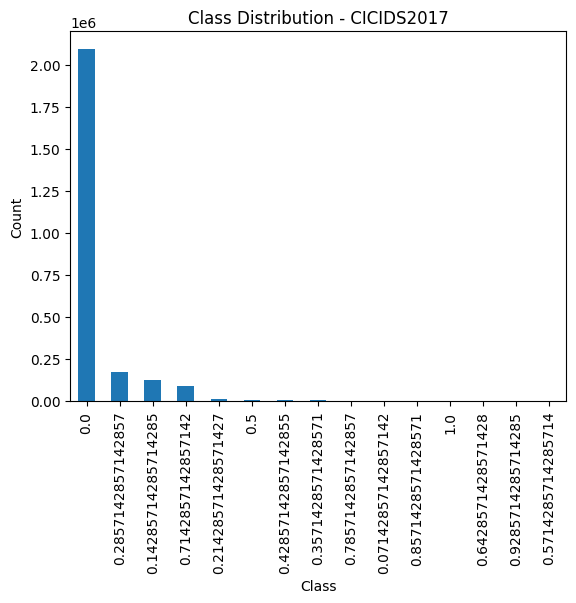

In [19]:
import matplotlib.pyplot as plt

df["Label"].value_counts().plot(kind="bar")

plt.title("Class Distribution - CICIDS2017")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

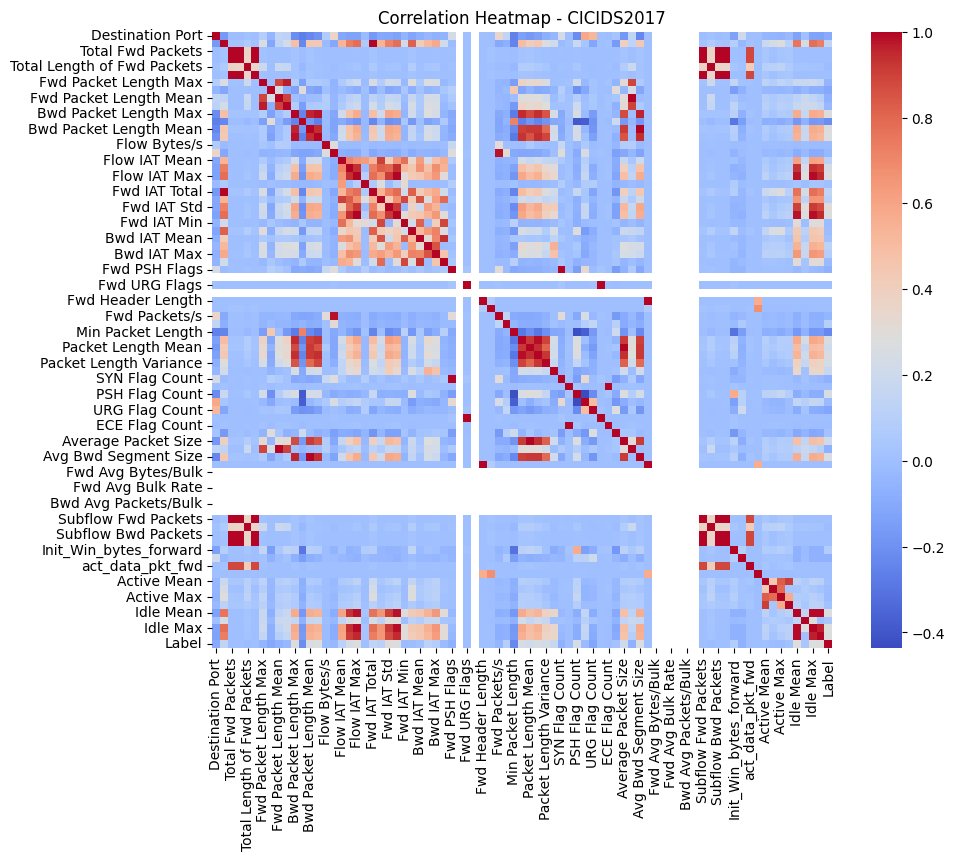

In [18]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap - CICIDS2017")

plt.show()

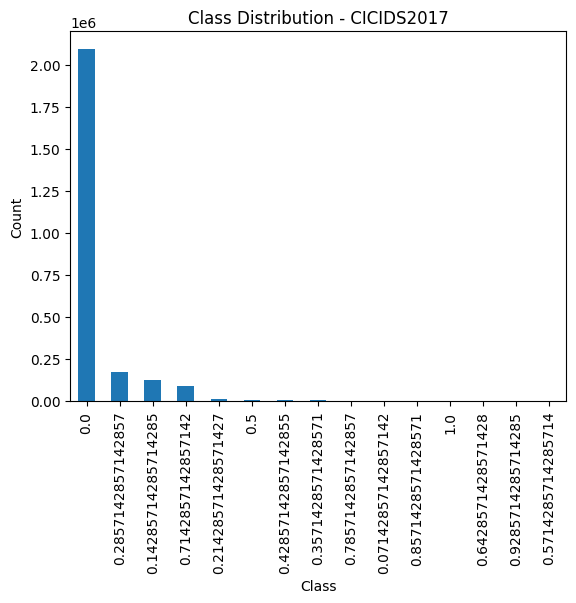

In [20]:
import matplotlib.pyplot as plt

df["Label"].value_counts().plot(kind="bar")

plt.title("Class Distribution - CICIDS2017")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [2]:
# Minority class percentage and imbalance ratio report
# Make this cell runnable on its own if df is not already in memory.
import os
import glob
import pandas as pd

if "df" not in globals():
    cleaned_path = "../data_processed/cicids2017_cleaned.csv"
    if os.path.exists(cleaned_path):
        df = pd.read_csv(cleaned_path)
    else:
        files = glob.glob("../data_raw/cic-ids-2017/MachineLearningCVE/*.csv")
        if not files:
            raise FileNotFoundError("CICIDS2017 source files not found in ../data_raw/cic-ids-2017/MachineLearningCVE/")
        df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
        df.columns = df.columns.str.strip()

label_col = "Label" if "Label" in df.columns else "label" if "label" in df.columns else None
if label_col is None:
    raise KeyError("No label column found. Expected 'Label' or 'label'.")

class_counts = df[label_col].value_counts().sort_values(ascending=False)

total_samples = class_counts.sum()
minority_class = class_counts.idxmin()
minority_count = class_counts.min()
majority_count = class_counts.max()

minority_percentage = (minority_count / total_samples) * 100
imbalance_ratio = majority_count / minority_count

class_report = (class_counts / total_samples * 100).rename("percentage").reset_index()
class_report.columns = ["class", "percentage"]

print("Minority class:", minority_class)
print("Minority class count:", minority_count)
print("Minority class percentage: {:.4f}%".format(minority_percentage))
print("Imbalance ratio (majority/minority): {:.4f}".format(imbalance_ratio))

class_report

Minority class: 0.5714285714285714
Minority class count: 11
Minority class percentage: 0.0004%
Imbalance ratio (majority/minority): 190459.7273


,class,percentage
0,0.000000,83.110864
1,0.285714,6.856797
2,0.142857,5.078313
3,0.714286,3.597829
4,0.214286,0.408045
5,0.500000,0.235283
6,0.428571,0.213623
7,0.357143,0.207395
8,0.785714,0.127698
9,0.071429,0.077277


In [21]:
df.to_csv("../data_processed/cicids2017_cleaned.csv", index=False)